<a href="https://colab.research.google.com/github/thanh-huy/SIC_Excercies/blob/main/0703b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA với AutoEncoder tuyến tính

In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
# Import the common module.
import numpy as np
import os
# To maintain the execution result
np.random.seed(42)
tf.random.set_seed(42) #Multi seed --> Kiểm định thống kê trên multi seed

In [3]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [ ]:
def plot_image(image):
  plt.imshow(image, cmap="binary")
  plt.axis("off")

In [12]:
from re import X
np.random.seed(4)
def generate_3d_data(m,w1=0.1,w2=0.3, noise=0.1):
  angles = np.random.rand(m)*3*np.pi/2 - 0.5
  data = np.empty((m,3))
  data[:,0] = np.cos(angles) + np.sin(angles)/2 + noise*np.random.randn(m)/2
  data[:,1] = np.sin(angles)*0.7 + noise*np.random.randn(m)/2
  data[:,2] = data[:,0]*w1 + data[:,1]*w2 + noise*np.random.randn(m)
  return data


In [16]:
#Encode
np.random.seed(42)
tf.random.set_seed(42)
X_train = generate_3d_data(60)
X_train = X_train - X_train.mean(axis=0,keepdims=True)
#encoder
encoder = keras.models.Sequential([keras.Input(shape=(3,)),
                                   keras.layers.Dense(2)])
#decoder
decoder = keras.models.Sequential([keras.Input(shape=(2,)),
                                   keras.layers.Dense(3)])
#autoencoder
autoencoder = keras.models.Sequential([encoder,decoder])
autoencoder.compile(loss="mse",optimizer=keras.optimizers.SGD(learning_rate=1.5))
history = autoencoder.fit(X_train,X_train,epochs=20)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - loss: 0.2212
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2389
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1126
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2551
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0944 
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0204
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0130
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0179
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0326
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0452
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0295
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0116
Epoch 13/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0064
Epoch 14/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0052
Epoch 15/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0048
Epoch 16/20
2/2 ━━━━━━━━━━━━━━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


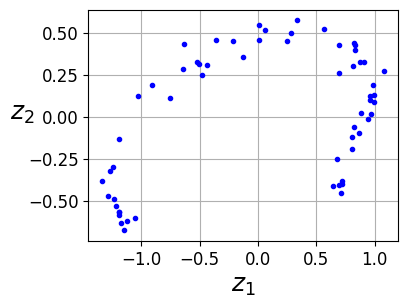

In [18]:
codings = encoder.predict(X_train)
fig = plt.figure(figsize=(4,3))
plt.plot(codings[:,0][:],codings[:,1][:],"b.")
plt.xlabel("$z_1$",fontsize=18)
plt.ylabel("$z_2$",fontsize=18,rotation=0)
plt.grid(True)
plt.show()